Let me figure out how to consider spirally aligned prolate grains here. The derivation will follow what I had in Appendix B of Lin et al. 2024, MNRAS, 528, 843. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
rad = np.pi / 180

In [2]:
# inclination of the disk
inc = 30 * rad

# s and t components
s = 0.01
t = 0.1

# chi: this is the alignment angle. 
# chi=0 is in the +radial direction
# chi=pi/2 is in the +Phi direction (following right hand rule)
# chi=pi is in the -radial direction, and so on. 
chi = 90 * rad

# disk azimuthal profile. Phi=0 is along the far side. 
Phi = np.linspace(-90, 270, 360) * rad
Phi_deg = Phi / rad

In [3]:
def analytical(s, t, i, Phi, chi):
    """
    This is the analytical equation we can derive. 
    """
    q = s + t * (np.cos(i)**2 * np.cos(Phi+chi)**2 - np.sin(Phi+chi)**2)
    u = t * np.cos(i) * np.sin(2 * (Phi + chi))
    return q, u

def numerical(s, t, i, Phi, chi):
    """
    Follow the derivation at each step to verify the derivation
    """
    # solve for the polar angle of the grain
    theta_g = np.arccos(- np.cos(Phi+chi) * np.sin(inc))

    # alpha
    alpha = np.pi - Phi - chi
    
    # psi
    cos_psi = - np.cos(theta_g) * np.cos(i) / np.sin(theta_g) / np.sin(i)
    sin_psi = np.sin(alpha) / np.sin(theta_g)
    psi = np.arctan2(sin_psi, cos_psi)

    # thermal polarization from particle
    tp = t * np.sin(theta_g)**2

    qp = tp * np.cos(2*psi)
    up = tp * np.sin(2*psi)

    q = s + qp
    u = up
    return q, u
    

In [4]:
# calculate 
q_ana, u_ana = analytical(s, t, inc, Phi, chi)
q_num, u_num = numerical(s, t, inc, Phi, chi)


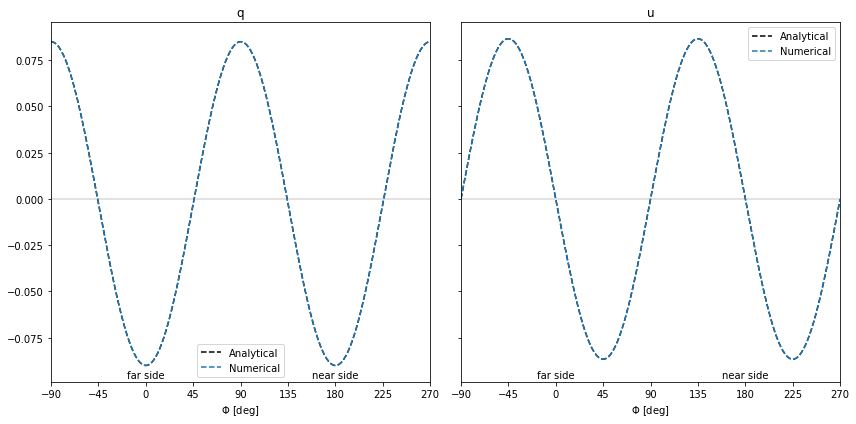

In [5]:
# plotting
fig, axes = plt.subplots(1,2,sharex=True,sharey=True,squeeze=True,figsize=(12,6))

tags = ['Analytical', 'Numerical']

ax = axes[0]
for q, tag, col in zip([q_ana, q_num], tags, ['k', 'C0']):
    ax.plot(Phi/rad, q, '--', label=tag, color=col)
ax.set_title('q')

ax = axes[1]
for u, tag, col in zip([u_ana, u_num], tags, ['k', 'C0']):
    ax.plot(Phi/rad, u, '--', label=tag, color=col)
ax.set_title('u')

for ax in axes:
    ax.legend()
    ax.set_xlabel(r'$\Phi$ [deg]')
    ax.set_xlim(Phi_deg[0], Phi_deg[-1])
    ax.set_xticks(np.arange(Phi_deg[0], Phi_deg[-1]+1, 45))
    ax.text(0.25, 0.005, 'far side', transform=ax.transAxes, va='bottom', ha='center')
    ax.text(0.75, 0.005, 'near side', transform=ax.transAxes, va='bottom', ha='center')
    ax.axhline(y=0, color='grey', alpha=0.3)

fig.tight_layout()
plt.show()